# Locally Weighted PLS (LWPLS)

LWPLS fits a local PLS model around each query point, weighting training samples by similarity to the query. Effective for nonlinear data where a global PLS model performs poorly.

`phi.lwpls(xnew, loc_par, mvm_pls, X_train, Y_train)` returns the scalar prediction for `xnew`.

Data: NIR tablet dataset (MATLAB format).

In [1]:
import scipy.io as spio
import numpy as np
import matplotlib.pyplot as plt
import pyphi.calc as phi
%matplotlib inline


Will be using the NEOS server in the absence of IPOPT and GAMS


## Load and Preprocess Data

In [2]:
NIRData = spio.loadmat('../data/NIRdata_tablets.MAT')
X = np.array(NIRData['Matrix'][:, 3:])
Y = np.array(NIRData['Matrix'][:, 0])

# Even-indexed rows = calibration; odd = validation
Xcal = X[::2, :]
Xval = X[1:X.shape[0]:2, :]

Xcal = phi.spectra_snv(Xcal)
Xval = phi.spectra_snv(Xval)
Xcal, _ = phi.spectra_savgol(5, 1, 2, Xcal)
Xval, _ = phi.spectra_savgol(5, 1, 2, Xval)

Ycal = Y[::2].reshape(-1, 1)
Yval = Y[1:X.shape[0]:2].reshape(-1, 1)
print('Cal:', Xcal.shape, Ycal.shape, '  Val:', Xval.shape, Yval.shape)


Cal: (155, 394) (155, 1)   Val: (155, 394) (155, 1)


## Global PLS Baseline

In [3]:
mvm_pls = phi.pls(Xcal, Ycal, 1, mcsX='center', mcsY='center')
pred_cal = phi.pls_pred(Xcal, mvm_pls)
pred_val = phi.pls_pred(Xval, mvm_pls)
rmse_pls_cal = float(np.sqrt(np.mean((Ycal - pred_cal['Yhat'])**2)))
rmse_pls_val = float(np.sqrt(np.mean((Yval - pred_val['Yhat'])**2)))
print(f'Global PLS  RMSE — CAL: {rmse_pls_cal:.4f}  VAL: {rmse_pls_val:.4f}')


phi.pls using NIPALS executed on: 2026-03-27 22:29:31.234904
# Iterations for LV #1:  1
--------------------------------------------------------------
LV #     Eig       R2X       sum(R2X)   R2Y       sum(R2Y)
LV #1:    0.000    0.520     0.520      0.932     0.932
--------------------------------------------------------------
Global PLS  RMSE — CAL: 0.3391  VAL: 0.3161


## LWPLS — Sweep Localization Parameter

Small `loc_par` = very local model; large = approaches global PLS. Tune by minimising validation RMSE.

In [4]:
loc_params = [5, 10, 15, 20, 25, 30, 40, 50, 100]
rmse_lw_cal, rmse_lw_val = [], []

for loc_par in loc_params:
    yhat_cal = np.array([
        phi.lwpls(Xcal[i, :], loc_par, mvm_pls, Xcal, Ycal, shush=True)[0]
        for i in range(Xcal.shape[0])
    ]).reshape(-1, 1)
    yhat_val = np.array([
        phi.lwpls(Xval[i, :], loc_par, mvm_pls, Xcal, Ycal, shush=True)[0]
        for i in range(Xval.shape[0])
    ]).reshape(-1, 1)

    rmse_lw_cal.append(float(np.sqrt(np.mean((Ycal - yhat_cal)**2))))
    rmse_lw_val.append(float(np.sqrt(np.mean((Yval - yhat_val)**2))))
    print(f'loc_par={loc_par:4d}  RMSE_CAL={rmse_lw_cal[-1]:.4f}  RMSE_VAL={rmse_lw_val[-1]:.4f}')


loc_par=   5  RMSE_CAL=0.0019  RMSE_VAL=0.2547


loc_par=  10  RMSE_CAL=0.0112  RMSE_VAL=0.2480


loc_par=  15  RMSE_CAL=0.0401  RMSE_VAL=0.2456


loc_par=  20  RMSE_CAL=0.0752  RMSE_VAL=0.2446


loc_par=  25  RMSE_CAL=0.0985  RMSE_VAL=0.2450


loc_par=  30  RMSE_CAL=0.1162  RMSE_VAL=0.2471


loc_par=  40  RMSE_CAL=0.1487  RMSE_VAL=0.2524


loc_par=  50  RMSE_CAL=0.1692  RMSE_VAL=0.2566


loc_par= 100  RMSE_CAL=0.2224  RMSE_VAL=0.2668


## RMSE vs Localization Parameter

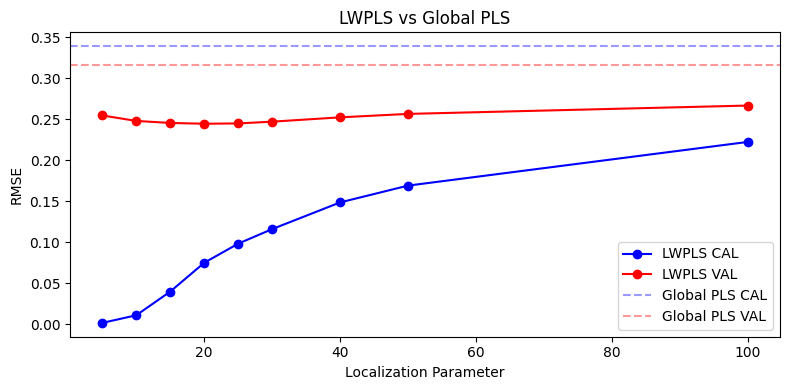

Best loc_par: 20  (Val RMSE: 0.2446)


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loc_params, rmse_lw_cal, 'o-b', label='LWPLS CAL')
ax.plot(loc_params, rmse_lw_val, 'o-r', label='LWPLS VAL')
ax.axhline(rmse_pls_cal, ls='--', color='b', alpha=0.4, label='Global PLS CAL')
ax.axhline(rmse_pls_val, ls='--', color='r', alpha=0.4, label='Global PLS VAL')
ax.set_xlabel('Localization Parameter')
ax.set_ylabel('RMSE')
ax.legend()
ax.set_title('LWPLS vs Global PLS')
plt.tight_layout()
plt.show()
best_idx = int(np.argmin(rmse_lw_val))
print(f'Best loc_par: {loc_params[best_idx]}  (Val RMSE: {rmse_lw_val[best_idx]:.4f})')
